# Monthly Dengue Case Prediction for Brazilian States using XGBoost

This notebook builds a Machine Learning project to predict the expected monthly dengue case count for each Brazilian state.  
The model uses previous dengue trends, climate variables, seasonality, population indicators, and state-level categorical encoding.

**Target:** `cases_total`  
**Model target used for training:** `log1p(cases_total)`  
**Main model:** XGBoost Regressor, Random Forest
**Split strategy:** Chronological 75% training and 25% testing, because this is a time-series forecasting problem.

## Step 1 — Import Libraries and Load the Dataset

In [56]:
!pip install xgboost -q

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import matthews_corrcoef, precision_score, recall_score, f1_score
from sklearn.base import clone

from xgboost import XGBRegressor

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [57]:
dataPath = "Brazil_UF_dengue_monthly.csv"

if not os.path.exists(dataPath):
    print("Please upload Brazil_UF_dengue_monthly.csv")
    uploadedFile = files.upload()
    dataPath = list(uploadedFile.keys())[0]

data = pd.read_csv(dataPath)

print("Dataset loaded successfully")
print("Dataset shape:", data.shape)

display(data.head())
display(data.info())

Dataset loaded successfully
Dataset shape: (6156, 62)


,Date,Year,Month,CD_UF,area_km2,NDVI_d,dewpoint_temperature_2m_d,humidity_d,max_temperature_2m_d,min_temperature_2m_d,surface_pressure_d,temperature_2m_d,total_precipitation_d,u_component_of_wind_10m_d,v_component_of_wind_10m_d,max_elevation_d,mean_elevation_d,min_elevation_d,stdDev_elevation_d,variance_elevation_d,Pop0_19_Urban_UF,PopTotal_Urban_UF,Pop0_19_Rural_UF,PopTotal_Rural_UF,Pop0_19_UF,PopTotal_UF,cases_total,cases0_19,cases20_99,Forest_Cover_Percent,Urban_Cover_Percent,ivs,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_e_trabalho,t_sem_agua_esgoto,t_sem_lixo,t_vulner_mais1h,t_analf_15m,t_cdom_fundin,t_p15a24_nada,t_vulner,t_desocup18m,t_p18m_fundin_informal,idhm,idhm_long,idhm_educ,idhm_renda,idhm_educ_sub_esc,t_pop18m_fundc,idhm_educ_sub_freq,renda_per_capita,pea10a14,pea15a17,pea18m,t_eletrica,t_densidadem2,rdpc_def_vulner,t_analf_18m,t_formal_18m,t_fundc_ocup18m,t_medioc_ocup18m
0,2001-01-01,2001,1,11,237765.347,0.154301,295.674980,88.460308,303.987216,294.155015,98872.990714,297.710208,2.857586,0.043359,-0.777382,499.574926,197.730512,94.780545,49.347551,2936.506226,423582,1149180,156693,413229,580275,1562409,668,169,499,98.394635,0.219764,0.319,0.231,0.400,0.325,12.43,5.36,4.73,8.73,34.25,10.29,33.33,5.19,41.10,0.690,0.800,0.577,0.712,0.480,48.00,0.633,670.82,18698,34904,723839,97.26,27.15,144.93,9.42,51.72,53.83,36.93
1,2001-01-01,2001,1,12,164173.431,0.168145,295.542503,88.487910,304.124060,294.199406,98582.531792,297.569555,2.552415,0.251881,-0.964689,376.525485,221.035752,134.591443,32.614629,1110.619048,222201,532279,102012,201280,324213,733559,1280,315,965,99.473600,0.096222,0.443,0.360,0.564,0.405,28.09,6.37,5.04,16.48,41.14,17.41,50.97,7.46,43.75,0.663,0.777,0.559,0.671,0.488,48.80,0.599,522.15,9054,11629,283968,91.14,46.05,119.68,17.79,46.45,55.20,39.61
2,2001-01-01,2001,1,13,1559167.878,0.139269,295.833200,89.794076,302.986562,294.787735,100308.794613,297.622061,3.627297,-0.812733,-0.392815,225.849212,73.236447,-1.247838,32.672174,1385.171273,1143830,2755490,376977,728495,1520807,3483985,7034,2099,4935,99.943627,0.035483,0.488,0.515,0.516,0.433,20.98,7.02,14.12,9.84,33.69,17.09,51.78,9.55,39.68,0.674,0.805,0.561,0.677,0.549,54.87,0.567,539.80,43891,57371,1371781,92.18,57.95,117.50,10.47,44.56,60.21,44.01
3,2001-01-01,2001,1,14,223644.527,0.260150,291.351277,59.916340,306.345735,294.559611,99530.968779,299.971856,0.298723,-2.601422,-1.302543,744.467660,141.341281,49.928330,65.152351,12694.573314,142324,344859,53544,105620,195868,450479,810,235,575,99.673823,0.083427,0.366,0.245,0.483,0.370,12.44,3.32,5.88,10.33,28.92,15.71,45.72,7.60,35.56,0.707,0.809,0.628,0.695,0.587,58.74,0.650,605.59,5441,8041,184044,90.73,51.22,115.71,11.01,47.99,66.08,50.44
4,2001-01-01,2001,1,15,1240882.471,0.143704,295.546890,88.441514,303.062775,294.656383,100189.284410,297.585123,4.078932,-0.962812,-0.714048,240.004804,85.238870,14.166812,35.330057,2730.591450,2023361,5191559,1118217,2389492,3141578,7581051,2464,726,1738,99.322985,0.042290,0.469,0.457,0.494,0.457,29.05,8.08,8.59,11.74,40.81,18.40,55.99,9.03,46.68,0.646,0.789,0.528,0.646,0.474,47.35,0.557,446.76,88495,126117,2992002,91.89,49.40,122.69,12.58,37.38,52.11,34.22


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6156 entries, 0 to 6155
Data columns (total 62 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       6156 non-null   object 
 1   Year                       6156 non-null   int64  
 2   Month                      6156 non-null   int64  
 3   CD_UF                      6156 non-null   int64  
 4   area_km2                   6156 non-null   float64
 5   NDVI_d                     6156 non-null   float64
 6   dewpoint_temperature_2m_d  6156 non-null   float64
 7   humidity_d                 6156 non-null   float64
 8   max_temperature_2m_d       6156 non-null   float64
 9   min_temperature_2m_d       6156 non-null   float64
 10  surface_pressure_d         6156 non-null   float64
 11  temperature_2m_d           6156 non-null   float64
 12  total_precipitation_d      6156 non-null   float64
 13  u_component_of_wind_10m_d  6156 non-null   float

None

## Step 2 — Number of Samples and Features

In [58]:
sampleCount = rawData.shape[0]
columnCount = rawData.shape[1]
inputFeatureCount = columnCount - 1

print("Number of samples:", sampleCount)
print("Number of total columns:", columnCount)
print("Number of input features if only cases_total is treated as target:", inputFeatureCount)

Number of samples: 6156
Number of total columns: 62
Number of input features if only cases_total is treated as target: 61


## Step 3 — Categorical and Numerical Attributes

`CD_UF` is stored as a number in the file, but it represents a Brazilian state code. Therefore, it is treated as a categorical state attribute during modeling.

In [59]:
sampleCount = data.shape[0]
featureCount = data.shape[1]

categoricalCols = data.select_dtypes(include=["object", "category"]).columns.tolist()
numericalCols = data.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print("Number of samples:", sampleCount)
print("Number of features:", featureCount)

print("\nNumber of categorical attributes:", len(categoricalCols))
print(categoricalCols)

print("\nNumber of numerical attributes:", len(numericalCols))
print(numericalCols)

Number of samples: 6156
Number of features: 62

Number of categorical attributes: 1
['Date']

Number of numerical attributes: 61
['Year', 'Month', 'CD_UF', 'area_km2', 'NDVI_d', 'dewpoint_temperature_2m_d', 'humidity_d', 'max_temperature_2m_d', 'min_temperature_2m_d', 'surface_pressure_d', 'temperature_2m_d', 'total_precipitation_d', 'u_component_of_wind_10m_d', 'v_component_of_wind_10m_d', 'max_elevation_d', 'mean_elevation_d', 'min_elevation_d', 'stdDev_elevation_d', 'variance_elevation_d', 'Pop0_19_Urban_UF', 'PopTotal_Urban_UF', 'Pop0_19_Rural_UF', 'PopTotal_Rural_UF', 'Pop0_19_UF', 'PopTotal_UF', 'cases_total', 'cases0_19', 'cases20_99', 'Forest_Cover_Percent', 'Urban_Cover_Percent', 'ivs', 'ivs_infraestrutura_urbana', 'ivs_capital_humano', 'ivs_renda_e_trabalho', 't_sem_agua_esgoto', 't_sem_lixo', 't_vulner_mais1h', 't_analf_15m', 't_cdom_fundin', 't_p15a24_nada', 't_vulner', 't_desocup18m', 't_p18m_fundin_informal', 'idhm', 'idhm_long', 'idhm_educ', 'idhm_renda', 'idhm_educ_sub_

## **Step4 : Automatic Column Detection**

In [60]:
def findExactCol(possibleNames, allCols):
    lowerMap = {col.lower(): col for col in allCols}
    for name in possibleNames:
        if name.lower() in lowerMap:
            return lowerMap[name.lower()]
    return None

def findKeywordCol(keywords, allCols):
    for col in allCols:
        low = col.lower()
        for key in keywords:
            if key.lower() in low:
                return col
    return None

dateCol = findExactCol(["Date", "date", "Month", "monthDate"], data.columns)
stateCol = findExactCol(["CD_UF", "UF", "state", "State", "SG_UF"], data.columns)
targetCol = findExactCol(["cases_total", "Cases_Total", "cases", "dengue_cases", "Dengue_cases"], data.columns)

if targetCol is None:
    targetCol = findKeywordCol(["cases_total", "dengue", "cases"], data.columns)

populationCol = findExactCol(["PopTotal_UF", "population", "Population", "popTotal", "PopTotal"], data.columns)
areaCol = findExactCol(["Area_UF", "area", "Area", "areaKm2"], data.columns)
urbanCol = findExactCol(["Urban_UF", "urban", "Urban", "urbanPopulation"], data.columns)
ruralCol = findExactCol(["Rural_UF", "rural", "Rural", "ruralPopulation"], data.columns)

precipCol = findKeywordCol(["precip", "rain", "prcp"], data.columns)
tempCol = findKeywordCol(["temp", "tmean", "temperature"], data.columns)
tempMaxCol = findKeywordCol(["tempmax", "temp_max", "tmax", "max_temp"], data.columns)
tempMinCol = findKeywordCol(["tempmin", "temp_min", "tmin", "min_temp"], data.columns)
humidityCol = findKeywordCol(["humidity", "relative_humidity", "rh"], data.columns)

print("Date column:", dateCol)
print("State column:", stateCol)
print("Target column:", targetCol)
print("Population column:", populationCol)
print("Area column:", areaCol)
print("Urban column:", urbanCol)
print("Rural column:", ruralCol)
print("Precipitation column:", precipCol)
print("Temperature column:", tempCol)
print("Maximum temperature column:", tempMaxCol)
print("Minimum temperature column:", tempMinCol)
print("Humidity column:", humidityCol)

if dateCol is None:
    raise ValueError("Date column was not found.")

if stateCol is None:
    raise ValueError("State or UF column was not found.")

if targetCol is None:
    raise ValueError("Dengue case target column was not found.")

Date column: Date
State column: CD_UF
Target column: cases_total
Population column: PopTotal_UF
Area column: None
Urban column: None
Rural column: None
Precipitation column: total_precipitation_d
Temperature column: dewpoint_temperature_2m_d
Maximum temperature column: max_temperature_2m_d
Minimum temperature column: min_temperature_2m_d
Humidity column: humidity_d


## **Step 5: Date Conversion and Sorting**

In [61]:
data[dateCol] = pd.to_datetime(data[dateCol], errors="coerce")

data = data.dropna(subset=[dateCol, stateCol, targetCol]).copy()
data[targetCol] = pd.to_numeric(data[targetCol], errors="coerce")
data = data.dropna(subset=[targetCol]).copy()

data = data.sort_values([stateCol, dateCol]).reset_index(drop=True)

data["year"] = data[dateCol].dt.year
data["month"] = data[dateCol].dt.month
data["quarter"] = data[dateCol].dt.quarter

print("Date range:", data[dateCol].min(), "to", data[dateCol].max())
print("Number of Brazilian states:", data[stateCol].nunique())

display(data[[dateCol, stateCol, targetCol, "year", "month"]].head())

Date range: 2001-01-01 00:00:00 to 2019-12-01 00:00:00
Number of Brazilian states: 27


,Date,CD_UF,cases_total,year,month
0,2001-01-01,11,668,2001,1
1,2001-02-01,11,275,2001,2
2,2001-03-01,11,173,2001,3
3,2001-04-01,11,80,2001,4
4,2001-05-01,11,109,2001,5


## Step 6 — Feature Engineering

The following feature groups are created:

1. Lag dengue features  
2. Rolling dengue trend features  
3. Cyclical time features  
4. Climate lag features  
5. Climate rolling statistics  
6. Incidence rate features using previous dengue values  
7. Population density  
8. Urbanization ratio  
9. Temperature range  
10. Weather interaction features  
11. Climate anomaly features  
12. State categorical feature  
13. Log-transformed target  
14. Leakage feature removal

Target-related current-month variables such as `cases_total`, `cases0_19`, and `cases20_99` are not used as input features.

In [62]:
modelData = data.copy()

modelData["targetLog"] = np.log1p(modelData[targetCol].clip(lower=0))

createdFeatures = []

# Lag Feature Engineering
for lag in [1, 2, 3, 6, 12]:
    colName = "casesLag" + str(lag)
    modelData[colName] = modelData.groupby(stateCol)[targetCol].shift(lag)
    createdFeatures.append(colName)

# Rolling Window Feature Engineering
for window in [3, 6, 12]:
    meanName = "casesRollingMean" + str(window)
    stdName = "casesRollingStd" + str(window)

    modelData[meanName] = modelData.groupby(stateCol)[targetCol].transform(
        lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
    )

    modelData[stdName] = modelData.groupby(stateCol)[targetCol].transform(
        lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
    )

    createdFeatures.extend([meanName, stdName])

# Cyclical Time Encoding
modelData["monthSin"] = np.sin(2 * np.pi * modelData["month"] / 12)
modelData["monthCos"] = np.cos(2 * np.pi * modelData["month"] / 12)
modelData["quarterSin"] = np.sin(2 * np.pi * modelData["quarter"] / 4)
modelData["quarterCos"] = np.cos(2 * np.pi * modelData["quarter"] / 4)

createdFeatures.extend(["year", "month", "quarter", "monthSin", "monthCos", "quarterSin", "quarterCos"])

# Climate Columns
climateCols = []
for col in [precipCol, tempCol, tempMaxCol, tempMinCol, humidityCol]:
    if col is not None and col not in climateCols:
        if pd.api.types.is_numeric_dtype(modelData[col]):
            climateCols.append(col)

print("Climate columns used:", climateCols)

# Current climate features
for col in climateCols:
    createdFeatures.append(col)

# Climate Lag Feature Engineering
for col in climateCols:
    for lag in [1, 2, 3]:
        lagName = str(col) + "Lag" + str(lag)
        modelData[lagName] = modelData.groupby(stateCol)[col].shift(lag)
        createdFeatures.append(lagName)

# Climate Rolling Statistics
for col in climateCols:
    for window in [3, 6]:
        meanName = str(col) + "RollingMean" + str(window)
        stdName = str(col) + "RollingStd" + str(window)

        modelData[meanName] = modelData.groupby(stateCol)[col].transform(
            lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
        )

        modelData[stdName] = modelData.groupby(stateCol)[col].transform(
            lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
        )

        createdFeatures.extend([meanName, stdName])

# Incidence Rate Feature Engineering
if populationCol is not None and pd.api.types.is_numeric_dtype(modelData[populationCol]):
    modelData["casesPer100kLag1"] = (modelData["casesLag1"] / modelData[populationCol].replace(0, np.nan)) * 100000
    modelData["populationLog"] = np.log1p(modelData[populationCol].clip(lower=0))
    createdFeatures.extend([populationCol, "casesPer100kLag1", "populationLog"])

# Population Density Feature
if populationCol is not None and areaCol is not None:
    if pd.api.types.is_numeric_dtype(modelData[populationCol]) and pd.api.types.is_numeric_dtype(modelData[areaCol]):
        modelData["populationDensity"] = modelData[populationCol] / modelData[areaCol].replace(0, np.nan)
        createdFeatures.extend([areaCol, "populationDensity"])

# Urbanization Ratio Feature
if urbanCol is not None and populationCol is not None:
    if pd.api.types.is_numeric_dtype(modelData[urbanCol]) and pd.api.types.is_numeric_dtype(modelData[populationCol]):
        modelData["urbanizationRatio"] = modelData[urbanCol] / modelData[populationCol].replace(0, np.nan)
        createdFeatures.extend([urbanCol, "urbanizationRatio"])

elif urbanCol is not None and ruralCol is not None:
    if pd.api.types.is_numeric_dtype(modelData[urbanCol]) and pd.api.types.is_numeric_dtype(modelData[ruralCol]):
        modelData["urbanizationRatio"] = modelData[urbanCol] / (modelData[urbanCol] + modelData[ruralCol]).replace(0, np.nan)
        createdFeatures.extend([urbanCol, ruralCol, "urbanizationRatio"])

# Temperature Range Feature
if tempMaxCol is not None and tempMinCol is not None:
    if pd.api.types.is_numeric_dtype(modelData[tempMaxCol]) and pd.api.types.is_numeric_dtype(modelData[tempMinCol]):
        modelData["temperatureRange"] = modelData[tempMaxCol] - modelData[tempMinCol]
        createdFeatures.append("temperatureRange")

# Weather Interaction Features
if precipCol is not None and tempCol is not None:
    if pd.api.types.is_numeric_dtype(modelData[precipCol]) and pd.api.types.is_numeric_dtype(modelData[tempCol]):
        modelData["precipTempInteraction"] = modelData[precipCol] * modelData[tempCol]
        createdFeatures.append("precipTempInteraction")

if humidityCol is not None and tempCol is not None:
    if pd.api.types.is_numeric_dtype(modelData[humidityCol]) and pd.api.types.is_numeric_dtype(modelData[tempCol]):
        modelData["humidityTempInteraction"] = modelData[humidityCol] * modelData[tempCol]
        createdFeatures.append("humidityTempInteraction")

# Climate Anomaly Feature Engineering
for col in climateCols:
    anomalyName = str(col) + "Anomaly"
    monthlyNormal = modelData.groupby([stateCol, "month"])[col].transform("mean")
    modelData[anomalyName] = modelData[col] - monthlyNormal
    createdFeatures.append(anomalyName)

# State categorical encoding will be done inside pipeline
createdFeatures.append(stateCol)

# Remove duplicate feature names
createdFeatures = list(dict.fromkeys(createdFeatures))

print("Shape after feature engineering:", modelData.shape)
print("Number of engineered features:", len(createdFeatures))
display(modelData.head())

Climate columns used: ['total_precipitation_d', 'dewpoint_temperature_2m_d', 'max_temperature_2m_d', 'min_temperature_2m_d', 'humidity_d']
Shape after feature engineering: (6156, 126)
Number of engineered features: 70


,Date,Year,Month,CD_UF,area_km2,NDVI_d,dewpoint_temperature_2m_d,humidity_d,max_temperature_2m_d,min_temperature_2m_d,surface_pressure_d,temperature_2m_d,total_precipitation_d,u_component_of_wind_10m_d,v_component_of_wind_10m_d,max_elevation_d,mean_elevation_d,min_elevation_d,stdDev_elevation_d,variance_elevation_d,Pop0_19_Urban_UF,PopTotal_Urban_UF,Pop0_19_Rural_UF,PopTotal_Rural_UF,Pop0_19_UF,PopTotal_UF,cases_total,cases0_19,cases20_99,Forest_Cover_Percent,Urban_Cover_Percent,ivs,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_e_trabalho,t_sem_agua_esgoto,t_sem_lixo,t_vulner_mais1h,t_analf_15m,t_cdom_fundin,t_p15a24_nada,t_vulner,t_desocup18m,t_p18m_fundin_informal,idhm,idhm_long,idhm_educ,idhm_renda,idhm_educ_sub_esc,t_pop18m_fundc,idhm_educ_sub_freq,renda_per_capita,pea10a14,pea15a17,pea18m,t_eletrica,t_densidadem2,rdpc_def_vulner,t_analf_18m,t_formal_18m,t_fundc_ocup18m,t_medioc_ocup18m,year,month,quarter,targetLog,casesLag1,casesLag2,casesLag3,casesLag6,casesLag12,casesRollingMean3,casesRollingStd3,casesRollingMean6,casesRollingStd6,casesRollingMean12,casesRollingStd12,monthSin,monthCos,quarterSin,quarterCos,total_precipitation_dLag1,total_precipitation_dLag2,total_precipitation_dLag3,dewpoint_temperature_2m_dLag1,dewpoint_temperature_2m_dLag2,dewpoint_temperature_2m_dLag3,max_temperature_2m_dLag1,max_temperature_2m_dLag2,max_temperature_2m_dLag3,min_temperature_2m_dLag1,min_temperature_2m_dLag2,min_temperature_2m_dLag3,humidity_dLag1,humidity_dLag2,humidity_dLag3,total_precipitation_dRollingMean3,total_precipitation_dRollingStd3,total_precipitation_dRollingMean6,total_precipitation_dRollingStd6,dewpoint_temperature_2m_dRollingMean3,dewpoint_temperature_2m_dRollingStd3,dewpoint_temperature_2m_dRollingMean6,dewpoint_temperature_2m_dRollingStd6,max_temperature_2m_dRollingMean3,max_temperature_2m_dRollingStd3,max_temperature_2m_dRollingMean6,max_temperature_2m_dRollingStd6,min_temperature_2m_dRollingMean3,min_temperature_2m_dRollingStd3,min_temperature_2m_dRollingMean6,min_temperature_2m_dRollingStd6,humidity_dRollingMean3,humidity_dRollingStd3,humidity_dRollingMean6,humidity_dRollingStd6,casesPer100kLag1,populationLog,temperatureRange,precipTempInteraction,humidityTempInteraction,total_precipitation_dAnomaly,dewpoint_temperature_2m_dAnomaly,max_temperature_2m_dAnomaly,min_temperature_2m_dAnomaly,humidity_dAnomaly
0,2001-01-01,2001,1,11,237765.347,0.154301,295.674980,88.460308,303.987216,294.155015,98872.990714,297.710208,2.857586,0.043359,-0.777382,499.574926,197.730512,94.780545,49.347551,2936.506226,423582,1149180,156693,413229,580275,1562409,668,169,499,98.394635,0.219764,0.319,0.231,0.4,0.325,12.43,5.36,4.73,8.73,34.25,10.29,33.33,5.19,41.1,0.69,0.8,0.577,0.712,0.48,48.0,0.633,670.82,18698,34904,723839,97.26,27.15,144.93,9.42,51.72,53.83,36.93,2001,1,1,6.505784,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,8.660254e-01,1.000000e+00,6.123234e-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.26174,9.832201,844.916751,26155.499827,-0.324578,-0.657065,-1.223767,-0.651605,-0.551006
1,2001-02-01,2001,2,11,237765.347,0.216873,295.944060,88.856948,304.738755,294.332566,98783.092902,297.907907,2.795704,-0.011420,-0.706109,499.574926,197.730512,94.780545,49.347551,2936.506226,423582,1149180,156693,413229,580275,1562409,275,68,207,98.394635,0.219764,0.319,0.231,0.4,0.325,12.43,5.36,4.73,8.73,34.25,10.29,33.33,5.19,41.1,0.69,0.8,0.577,0.712,0.48,48.0,0.633,670.82,18698,34904,723839,97.26,27.15,144.93,9.42,51.72,53.83,36.93,2001,2,1,5.620401,668.0,NaN,NaN,NaN,NaN,668.0,NaN,668.0,NaN,668.0,NaN,0.866025,5.000000e-01,1.000000e+00,6.123234e-17,2.857586,NaN,NaN,295.674980,NaN,NaN,303.987216,NaN,NaN,294.155015,NaN,NaN,88.460308,NaN,NaN,2.857586,NaN,2.857586,NaN,295.674980,NaN,295.674980,NaN,303.987216,NaN,303.987216,NaN,294.155015,NaN,294.155015,NaN,88.460308,NaN,88.460308,NaN,42.754490,14.26174,10.406189,827.371873,26296.6

## Step7 : Leakage Feature Removal and Final Feature List

The model must not use current-month dengue target information as predictors. The leakage columns below are removed from the input feature list.

In [63]:
leakageCols = [targetCol, "targetLog", dateCol]

safeFeatures = []

for col in createdFeatures:
    if col in leakageCols:
        continue

    if col == stateCol:
        safeFeatures.append(col)
        continue

    if col not in modelData.columns:
        continue

    if not pd.api.types.is_numeric_dtype(modelData[col]):
        continue

    low = str(col).lower()

    # remove direct raw dengue/case columns unless they are engineered lag/rolling/incidence features
    if col != targetCol:
        if ("case" in low or "dengue" in low or "incid" in low):
            allowedWords = ["lag", "rolling", "per100k"]
            if not any(word in low for word in allowedWords):
                continue

    safeFeatures.append(col)

featureCols = list(dict.fromkeys(safeFeatures))

print("Final number of selected features:", len(featureCols))
print(featureCols)

Final number of selected features: 70
['casesLag1', 'casesLag2', 'casesLag3', 'casesLag6', 'casesLag12', 'casesRollingMean3', 'casesRollingStd3', 'casesRollingMean6', 'casesRollingStd6', 'casesRollingMean12', 'casesRollingStd12', 'year', 'month', 'quarter', 'monthSin', 'monthCos', 'quarterSin', 'quarterCos', 'total_precipitation_d', 'dewpoint_temperature_2m_d', 'max_temperature_2m_d', 'min_temperature_2m_d', 'humidity_d', 'total_precipitation_dLag1', 'total_precipitation_dLag2', 'total_precipitation_dLag3', 'dewpoint_temperature_2m_dLag1', 'dewpoint_temperature_2m_dLag2', 'dewpoint_temperature_2m_dLag3', 'max_temperature_2m_dLag1', 'max_temperature_2m_dLag2', 'max_temperature_2m_dLag3', 'min_temperature_2m_dLag1', 'min_temperature_2m_dLag2', 'min_temperature_2m_dLag3', 'humidity_dLag1', 'humidity_dLag2', 'humidity_dLag3', 'total_precipitation_dRollingMean3', 'total_precipitation_dRollingStd3', 'total_precipitation_dRollingMean6', 'total_precipitation_dRollingStd6', 'dewpoint_temperatur

## Step 8— Missing Value Handling with an Appropriate Strategy

Some lag, rolling, and anomaly features naturally contain missing values at the beginning of each state time series.  
The notebook imputes missing values **inside the ML pipeline** so that imputation is learned from the training data only.

Strategy:

- Numerical features: median imputation  
- Categorical features: most frequent value imputation  
- State code: one-hot encoding after imputation

In [64]:
X = modelData[featureCols].copy()
y = modelData["targetLog"].copy()

categoricalFeatures = [stateCol]
numericalFeatures = [col for col in featureCols if col != stateCol]

print("Numerical features:", len(numericalFeatures))
print("Categorical features:", categoricalFeatures)

print("\nTop missing values before pipeline imputation:")
display(X.isna().sum().sort_values(ascending=False).head(25))

Numerical features: 69
Categorical features: ['CD_UF']

Top missing values before pipeline imputation:


,0
casesLag12,324
casesLag6,162
casesLag3,81
dewpoint_temperature_2m_dLag3,81
min_temperature_2m_dLag3,81
max_temperature_2m_dLag3,81
total_precipitation_dLag3,81
humidity_dLag3,81
casesLag2,54
max_temperature_2m_dRollingStd6,54


## Step 9 — Weakest Correlation with the Target

Correlation is checked against the log-transformed target. A weak correlation does not always mean a feature is useless for XGBoost, because XGBoost can use nonlinear feature interactions. Still, this check helps understand feature relevance.

In [65]:
corrData = modelData[numericalFeatures + ["targetLog"]].copy()
corrResult = corrData.corr(numeric_only=True)["targetLog"].drop("targetLog")

weakestCorr = corrResult.reindex(corrResult.abs().sort_values().index)

print("Weakest correlation features with target:")
display(weakestCorr.head(15))

print("Strongest correlation features with target:")
display(weakestCorr.tail(15))

Weakest correlation features with target:


,targetLog
total_precipitation_dAnomaly,-0.005468
humidity_dRollingMean3,0.006948
max_temperature_2m_d,-0.011052
humidity_dAnomaly,-0.012734
humidity_dRollingStd3,0.013597
total_precipitation_dLag3,0.019080
humidity_dLag2,0.023041
total_precipitation_dRollingStd6,-0.025250
total_precipitation_d,0.032181
precipTempInteraction,0.035524


Strongest correlation features with target:


,targetLog
casesRollingMean6,0.307320
temperatureRange,-0.307620
max_temperature_2m_dRollingMean6,0.308661
min_temperature_2m_dLag1,0.319128
min_temperature_2m_dLag3,0.319986
casesLag2,0.330181
casesRollingStd3,0.333865
min_temperature_2m_dRollingMean3,0.339929
casesRollingStd12,0.341173
min_temperature_2m_dLag2,0.342317


## Step 10 — Chronological Training and Testing Split

A random train-test split is avoided because dengue forecasting is time-dependent.  
The first 75% of months are used for training and the last 25% of months are used for testing.

In [66]:
# Sort by date first for correct time-based ML splitting
modelDataSorted = modelData.sort_values([dateCol, stateCol]).reset_index(drop=True)

X = modelDataSorted[featureCols].copy()
y = modelDataSorted["targetLog"].copy()
actualCases = modelDataSorted[targetCol].copy()

uniqueDates = np.sort(modelDataSorted[dateCol].dropna().unique())

splitIndex = int(len(uniqueDates) * 0.75)
splitDate = uniqueDates[splitIndex]

trainMask = modelDataSorted[dateCol] < splitDate
testMask = modelDataSorted[dateCol] >= splitDate

Xtrain = X.loc[trainMask].copy()
Xtest = X.loc[testMask].copy()
ytrain = y.loc[trainMask].copy()
ytest = y.loc[testMask].copy()

testActualCases = actualCases.loc[testMask].copy()
testDates = modelDataSorted.loc[testMask, dateCol].copy()
testStates = modelDataSorted.loc[testMask, stateCol].copy()

print("Split date:", splitDate)
print("Training samples:", Xtrain.shape[0])
print("Testing samples:", Xtest.shape[0])
print("Training percentage:", round(100 * Xtrain.shape[0] / X.shape[0], 2))
print("Testing percentage:", round(100 * Xtest.shape[0] / X.shape[0], 2))

Split date: 2015-04-01T00:00:00.000000000
Training samples: 4617
Testing samples: 1539
Training percentage: 75.0
Testing percentage: 25.0


## Step 11 — Evaluation Metrics for the ML Model

For dengue case prediction, this is a **regression problem**, so normal classification accuracy is not the main metric.

Useful metrics:

- **MAE:** average absolute error in real dengue case numbers. Easy to understand.
- **RMSE:** penalizes large outbreak errors more strongly.
- **R² in log scale:** explains how well the model predicts the stabilized target.
- **R² in real scale:** explains performance after converting predictions back to case counts.
- **MCC:** not a regression metric, but useful if monthly cases are converted into a high-outbreak vs non-high-outbreak class. Here, high outbreak is defined using the 75th percentile of training case counts.
- **Outbreak accuracy:** classification accuracy for the same high-outbreak conversion.

The main regression metrics are MAE, RMSE, and R². MCC is included only because it was requested for performance comparison plots.

In [67]:
def safeMape(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    mask = actual != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def safeWape(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)

    denominator = np.sum(np.abs(actual))

    if denominator == 0:
        return np.nan

    return np.sum(np.abs(actual - predicted)) / denominator * 100

def regressionReport(yTrueLog, yPredLog, actualCaseValues):
    predictedCases = np.expm1(yPredLog)
    predictedCases = np.clip(predictedCases, 0, None)

    actualCaseValues = np.array(actualCaseValues)

    mae = mean_absolute_error(actualCaseValues, predictedCases)
    rmse = np.sqrt(mean_squared_error(actualCaseValues, predictedCases))
    r2Log = r2_score(yTrueLog, yPredLog)
    mape = safeMape(actualCaseValues, predictedCases)
    wape = safeWape(actualCaseValues, predictedCases)
    accuracyLike = max(0, 100 - wape)

    return {
        "MAE cases": mae,
        "RMSE cases": rmse,
        "R2 log scale": r2Log,
        "MAPE percent": mape,
        "WAPE percent": wape,
        "Accuracy like percent": accuracyLike
    }

def outbreakReport(actualCaseValues, predictedCaseValues, threshold):
    actualLabel = (np.array(actualCaseValues) >= threshold).astype(int)
    predictedLabel = (np.array(predictedCaseValues) >= threshold).astype(int)

    return {
        "MCC": matthews_corrcoef(actualLabel, predictedLabel),
        "Precision": precision_score(actualLabel, predictedLabel, zero_division=0),
        "Recall": recall_score(actualLabel, predictedLabel, zero_division=0),
        "F1": f1_score(actualLabel, predictedLabel, zero_division=0)
    }

## Step 12 — Build Preprocessing Pipeline

In [68]:
numericTransformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categoricalTransformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numericTransformer, numericalFeatures),
        ("cat", categoricalTransformer, categoricalFeatures)
    ],
    remainder="drop"
)

Step 13: Train XGBoost with Hyperparameter Tuning

In [69]:
xgbBase = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgbPipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgbBase)
])

xgbParams = {
    "model__n_estimators": [300, 500, 700, 900],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.08],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__reg_alpha": [0, 0.01, 0.1],
    "model__reg_lambda": [1, 2, 5, 10]
}

timeSplit = TimeSeriesSplit(n_splits=4)

xgbSearch = RandomizedSearchCV(
    estimator=xgbPipe,
    param_distributions=xgbParams,
    n_iter=5,
    scoring="neg_mean_absolute_error",
    cv=timeSplit,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgbSearch.fit(Xtrain, ytrain)

bestXgbModel = xgbSearch.best_estimator_

print("Best XGBoost parameters:")
print(xgbSearch.best_params_)
print("Best XGBoost CV score:", xgbSearch.best_score_)

Fitting 4 folds for each of 5 candidates, totalling 20 fits
Best XGBoost parameters:
{'model__subsample': 0.9, 'model__reg_lambda': 2, 'model__reg_alpha': 0.01, 'model__n_estimators': 900, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Best XGBoost CV score: -0.3945282607947813


## Step 14 — Train Random Forest with Hyperparameter Tuning

In [70]:
rfBase = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rfPipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", rfBase)
])

rfParams = {
    "model__n_estimators": [300, 500, 700, 900],
    "model__max_depth": [8, 12, 16, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5, 0.8]
}

rfSearch = RandomizedSearchCV(
    estimator=rfPipe,
    param_distributions=rfParams,
    n_iter=5,
    scoring="neg_mean_absolute_error",
    cv=timeSplit,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rfSearch.fit(Xtrain, ytrain)

bestRfModel = rfSearch.best_estimator_

print("Best Random Forest parameters:")
print(rfSearch.best_params_)
print("Best Random Forest CV score:", rfSearch.best_score_)

Fitting 4 folds for each of 5 candidates, totalling 20 fits
Best Random Forest parameters:
{'model__n_estimators': 700, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 0.8, 'model__max_depth': 12}
Best Random Forest CV score: -0.3906858458980897


## Step 15 — Test Data Prediction and Accuracy

In [71]:
xgbPredLog = bestXgbModel.predict(Xtest)
rfPredLog = bestRfModel.predict(Xtest)

xgbPredCases = np.clip(np.expm1(xgbPredLog), 0, None)
rfPredCases = np.clip(np.expm1(rfPredLog), 0, None)

xgbMetrics = regressionReport(ytest, xgbPredLog, testActualCases)
rfMetrics = regressionReport(ytest, rfPredLog, testActualCases)

metricsTable = pd.DataFrame([xgbMetrics, rfMetrics], index=["XGBoost", "Random Forest"])

display(metricsTable)

bestModelName = metricsTable["MAE cases"].idxmin()
print("Best model based on MAE:", bestModelName)
print("Best model based on accuracy-like percent:", metricsTable["Accuracy like percent"].idxmax())

,MAE cases,RMSE cases,R2 log scale,MAPE percent,WAPE percent,Accuracy like percent
XGBoost,1110.468384,6038.325927,0.931728,52.788500,37.103996,62.896004
Random Forest,1171.241502,6996.426145,0.939178,41.834161,39.134605,60.865395


Best model based on MAE: XGBoost
Best model based on accuracy-like percent: XGBoost


## Step 11 MCC Outbreak Detection Comparison


In [72]:
outbreakThreshold = np.percentile(modelDataSorted.loc[trainMask, targetCol], 75)

xgbOutbreak = outbreakReport(testActualCases, xgbPredCases, outbreakThreshold)
rfOutbreak = outbreakReport(testActualCases, rfPredCases, outbreakThreshold)

mccTable = pd.DataFrame([xgbOutbreak, rfOutbreak], index=["XGBoost", "Random Forest"])

print("Outbreak threshold:", outbreakThreshold)
display(mccTable)

Outbreak threshold: 1106.0


,MCC,Precision,Recall,F1
XGBoost,0.890400,0.898077,0.955010,0.925669
Random Forest,0.881198,0.925311,0.912065,0.918641


## Step 11 — Prediction Result Table

In [73]:
resultTable = pd.DataFrame({
    "date": testDates.values,
    "state": testStates.values,
    "actual cases": testActualCases.values,
    "xgboost predicted cases": xgbPredCases,
    "random forest predicted cases": rfPredCases
})

display(resultTable.head(20))

,date,state,actual cases,xgboost predicted cases,random forest predicted cases
0,2015-04-01,11,273,242.922836,219.459478
1,2015-04-01,12,268,403.393921,494.246484
2,2015-04-01,13,517,695.636475,522.202726
3,2015-04-01,14,111,80.777893,75.454529
4,2015-04-01,15,1047,1250.836182,987.463986
5,2015-04-01,16,440,720.657104,672.607946
6,2015-04-01,17,1292,1674.849731,1392.254314
7,2015-04-01,21,1782,2819.534424,2046.823684
8,2015-04-01,22,2279,3346.406250,2497.687580
9,2015-04-01,23,11030,9518.353516,7567.921677


Graph 1: Actual vs Predicted Cases

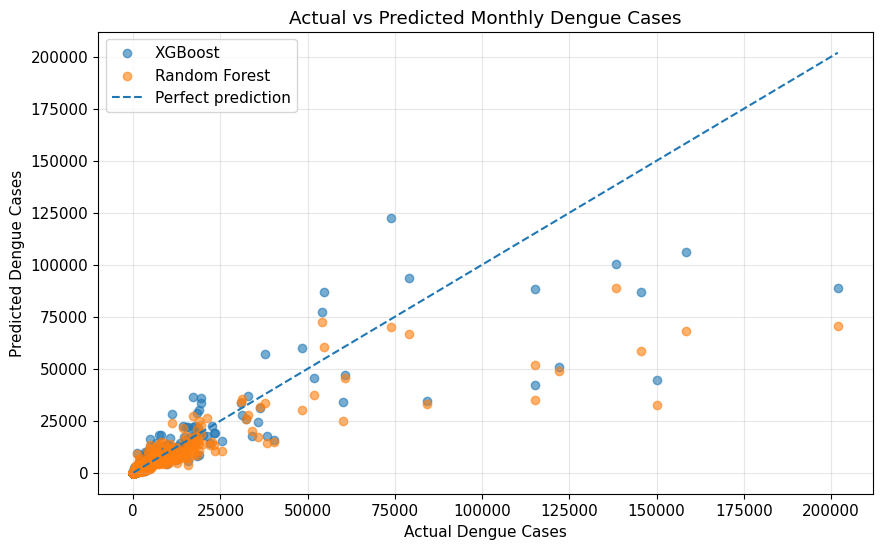

In [76]:
plt.figure(figsize=(10, 6))

plt.scatter(resultTable["actual cases"], resultTable["xgboost predicted cases"], alpha=0.6, label="XGBoost")
plt.scatter(resultTable["actual cases"], resultTable["random forest predicted cases"], alpha=0.6, label="Random Forest")

maxValue = max(
    resultTable["actual cases"].max(),
    resultTable["xgboost predicted cases"].max(),
    resultTable["random forest predicted cases"].max()
)

plt.plot([0, maxValue], [0, maxValue], linestyle="--", label="Perfect prediction")

plt.xlabel("Actual Dengue Cases")
plt.ylabel("Predicted Dengue Cases")
plt.title("Actual vs Predicted Monthly Dengue Cases")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Graph 2: Regression Performance Comparison

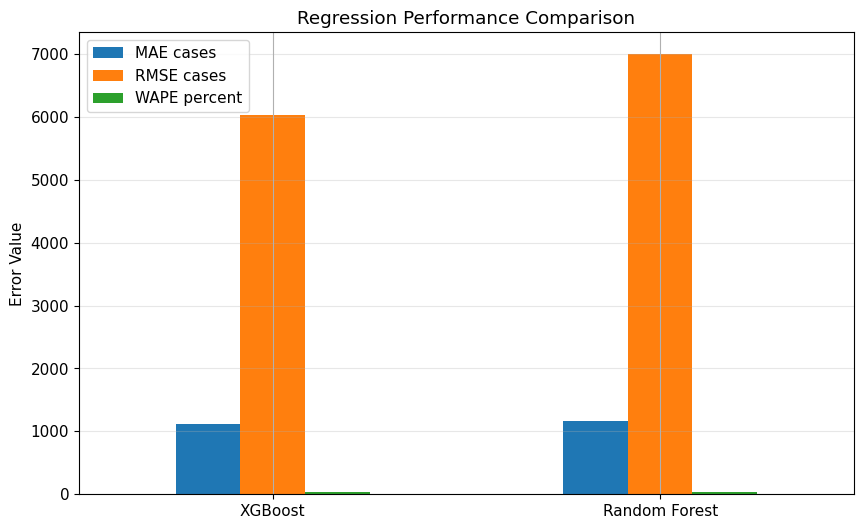

In [77]:
plotMetrics = metricsTable[["MAE cases", "RMSE cases", "WAPE percent"]].copy()

plotMetrics.plot(kind="bar", figsize=(10, 6))

plt.title("Regression Performance Comparison")
plt.ylabel("Error Value")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

Graph 3: MCC Performance Comparison

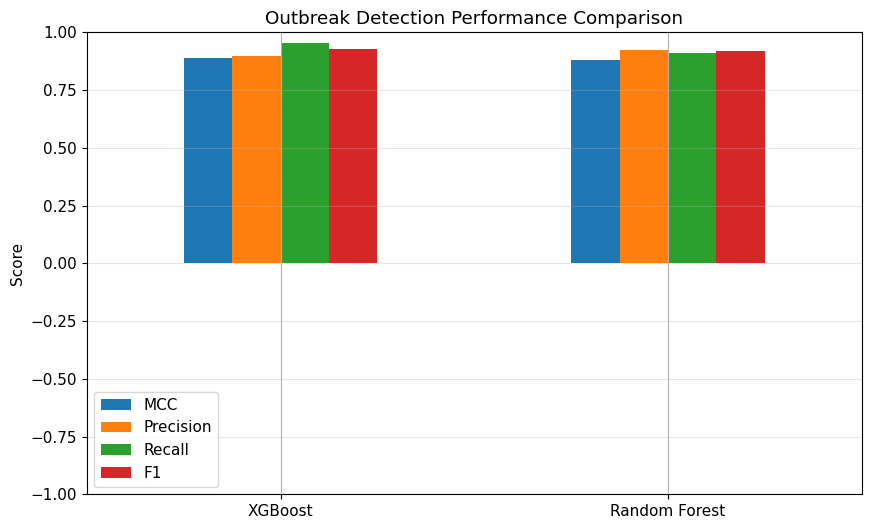

In [78]:
mccTable[["MCC", "Precision", "Recall", "F1"]].plot(kind="bar", figsize=(10, 6))

plt.title("Outbreak Detection Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(-1, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

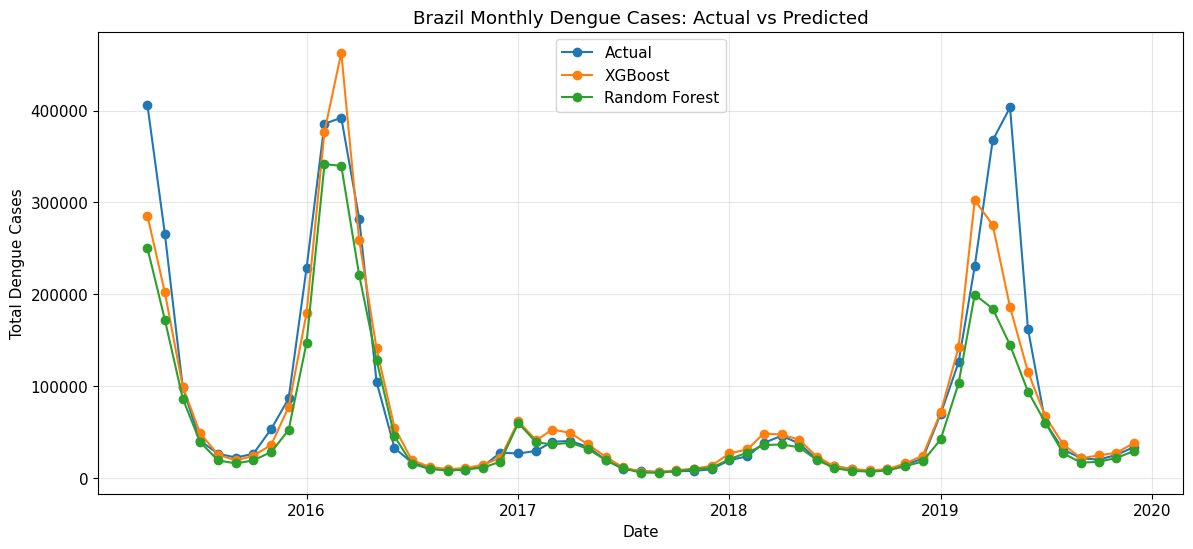

In [79]:
# Graph 4: Monthly Time-Series Comparison
monthlyComparison = resultTable.groupby("date")[
    ["actual cases", "xgboost predicted cases", "random forest predicted cases"]
].sum().reset_index()

plt.figure(figsize=(14, 6))

plt.plot(monthlyComparison["date"], monthlyComparison["actual cases"], marker="o", label="Actual")
plt.plot(monthlyComparison["date"], monthlyComparison["xgboost predicted cases"], marker="o", label="XGBoost")
plt.plot(monthlyComparison["date"], monthlyComparison["random forest predicted cases"], marker="o", label="Random Forest")

plt.xlabel("Date")
plt.ylabel("Total Dengue Cases")
plt.title("Brazil Monthly Dengue Cases: Actual vs Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 13 — Cross-Validation and Comparison with Train-Test Split

The cross-validation below uses expanding chronological folds. Each validation fold happens after its training fold, so the model is never trained on future data for that fold.

In [80]:
def crossValidationEvaluation(model, fullX, fullY, fullActual, splitCount=4):
    splitter = TimeSeriesSplit(n_splits=splitCount)
    rows = []

    for foldNumber, pair in enumerate(splitter.split(fullX), start=1):
        trainIndex, validIndex = pair

        foldXtrain = fullX.iloc[trainIndex]
        foldXvalid = fullX.iloc[validIndex]

        foldYtrain = fullY.iloc[trainIndex]
        foldYvalid = fullY.iloc[validIndex]

        foldActual = fullActual.iloc[validIndex]

        foldModel = clone(model)
        foldModel.fit(foldXtrain, foldYtrain)

        foldPredLog = foldModel.predict(foldXvalid)
        foldPredCases = np.clip(np.expm1(foldPredLog), 0, None)

        rows.append({
            "fold": foldNumber,
            "MAE cases": mean_absolute_error(foldActual, foldPredCases),
            "RMSE cases": np.sqrt(mean_squared_error(foldActual, foldPredCases)),
            "R2 log scale": r2_score(foldYvalid, foldPredLog),
            "MAPE percent": safeMape(foldActual, foldPredCases),
            "WAPE percent": safeWape(foldActual, foldPredCases),
            "Accuracy like percent": max(0, 100 - safeWape(foldActual, foldPredCases))
        })

    return pd.DataFrame(rows)

xgbCvResults = crossValidationEvaluation(bestXgbModel, X, y, actualCases, splitCount=4)
rfCvResults = crossValidationEvaluation(bestRfModel, X, y, actualCases, splitCount=4)

print("XGBoost cross-validation results")
display(xgbCvResults)

print("Random Forest cross-validation results")
display(rfCvResults)

cvSummary = pd.DataFrame({
    "XGBoost CV Mean": xgbCvResults.mean(numeric_only=True),
    "Random Forest CV Mean": rfCvResults.mean(numeric_only=True)
}).T

display(cvSummary)

XGBoost cross-validation results


,fold,MAE cases,RMSE cases,R2 log scale,MAPE percent,WAPE percent,Accuracy like percent
0,1,522.899658,2618.045072,0.913614,44.058897,44.216092,55.783908
1,2,769.075745,2901.869053,0.929233,42.960295,37.345955,62.654045
2,3,1592.595215,10050.853098,0.944867,36.806815,43.130292,56.869708
3,4,870.212952,4975.163314,0.928957,51.747251,36.608827,63.391173


Random Forest cross-validation results


,fold,MAE cases,RMSE cases,R2 log scale,MAPE percent,WAPE percent,Accuracy like percent
0,1,466.513324,2298.397019,0.919359,44.464093,39.448097,60.551903
1,2,823.223216,3195.624619,0.924455,42.609674,39.975329,60.024671
2,3,1628.464055,9857.118784,0.942643,33.380987,44.101681,55.898319
3,4,923.864656,6082.665444,0.937025,43.404606,38.865891,61.134109


,fold,MAE cases,RMSE cases,R2 log scale,MAPE percent,WAPE percent,Accuracy like percent
XGBoost CV Mean,2.5,938.695892,5136.482634,0.929168,43.893315,40.325291,59.674709
Random Forest CV Mean,2.5,960.516313,5358.451466,0.930870,40.964840,40.597750,59.402250


,Accuracy like percent,MAE cases,MAPE percent,R2 log scale,RMSE cases,WAPE percent,fold
XGBoost Train Test,62.896004,1110.468384,52.788500,0.931728,6038.325927,37.103996,NaN
Random Forest Train Test,60.865395,1171.241502,41.834161,0.939178,6996.426145,39.134605,NaN
XGBoost CV Mean,59.674709,938.695892,43.893315,0.929168,5136.482634,40.325291,2.5
Random Forest CV Mean,59.402250,960.516313,40.964840,0.930870,5358.451466,40.597750,2.5


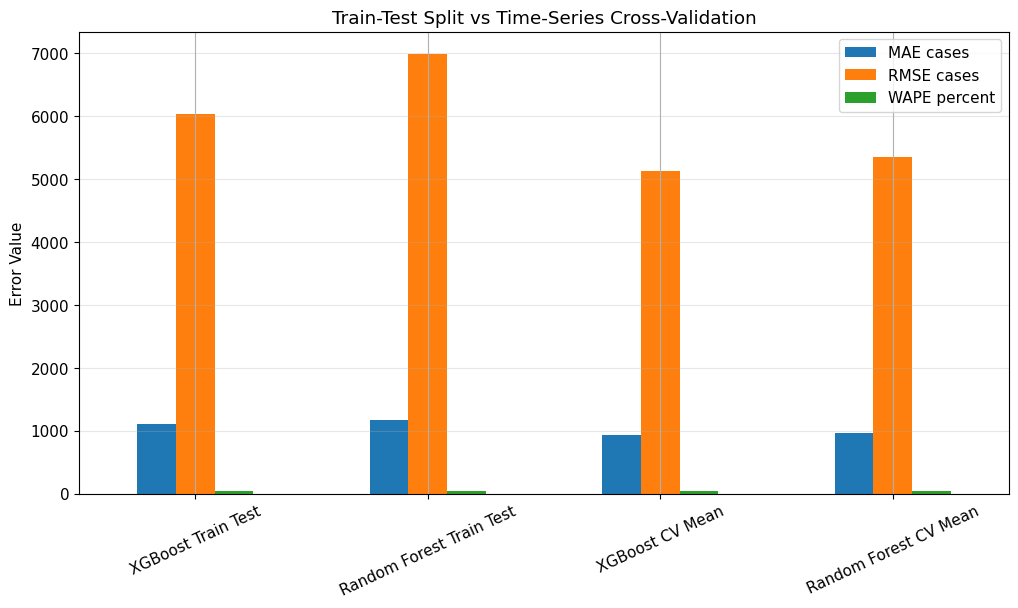

In [81]:
#Compare Cross-Validation with Train-Test Split
comparisonTable = pd.DataFrame({
    "XGBoost Train Test": metricsTable.loc["XGBoost"],
    "Random Forest Train Test": metricsTable.loc["Random Forest"],
    "XGBoost CV Mean": cvSummary.loc["XGBoost CV Mean"],
    "Random Forest CV Mean": cvSummary.loc["Random Forest CV Mean"]
}).T

display(comparisonTable)

comparisonTable[["MAE cases", "RMSE cases", "WAPE percent"]].plot(kind="bar", figsize=(12, 6))

plt.title("Train-Test Split vs Time-Series Cross-Validation")
plt.ylabel("Error Value")
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)
plt.show()

Feature Importance from XGBoost

,feature,importance
0,casesLag1,0.623564
17,quarterCos,0.112056
12,month,0.017866
2,casesLag3,0.009432
15,monthCos,0.008431
4,casesLag12,0.007815
91,CD_UF_43,0.006982
73,CD_UF_15,0.006809
62,precipTempInteraction,0.006765
58,PopTotal_UF,0.006741


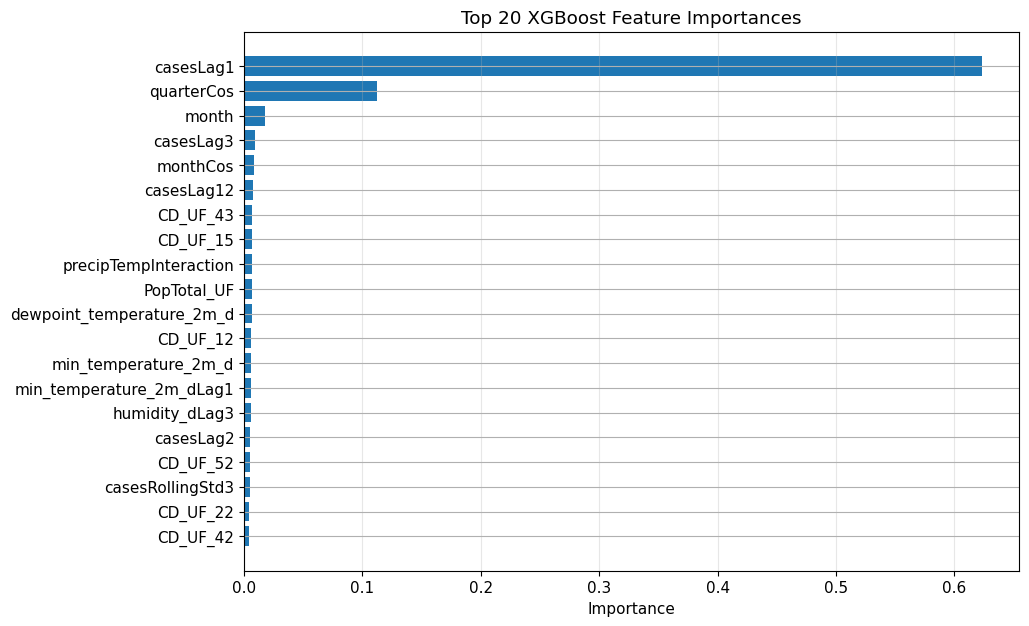

In [82]:
def getFeatureNames(fittedPreprocessor):
    allNames = []

    numericNames = fittedPreprocessor.named_transformers_["num"].get_feature_names_out(numericalFeatures)
    allNames.extend(numericNames)

    catEncoder = fittedPreprocessor.named_transformers_["cat"].named_steps["onehot"]
    catNames = catEncoder.get_feature_names_out(categoricalFeatures)
    allNames.extend(catNames)

    return np.array(allNames)

try:
    featureNames = getFeatureNames(bestXgbModel.named_steps["preprocess"])
    importances = bestXgbModel.named_steps["model"].feature_importances_

    importanceTable = pd.DataFrame({
        "feature": featureNames,
        "importance": importances
    }).sort_values("importance", ascending=False)

    display(importanceTable.head(20))

    topImportance = importanceTable.head(20).sort_values("importance")

    plt.figure(figsize=(10, 7))
    plt.barh(topImportance["feature"], topImportance["importance"])
    plt.title("Top 20 XGBoost Feature Importances")
    plt.xlabel("Importance")
    plt.grid(axis="x", alpha=0.3)
    plt.show()

except Exception as error:
    print("Feature importance could not be displayed.")
    print(error)

## Final Notes

This project uses a time-aware regression approach for dengue forecasting. XGBoost is appropriate here because it works well on structured tabular data, handles nonlinear relations, and can capture interactions between lagged dengue counts, climate patterns, state differences, and population conditions.

The most important caution is leakage control. Current-month dengue counts and age-specific current-month dengue counts are removed from the features. Lagged dengue values are allowed because they represent previous information available before forecasting the next month.